In [25]:
# 00. 데이터 불러오기
import pandas as pd

portfolio = pd.read_csv("portfolio.csv", encoding='utf-8')
profile = pd.read_csv("profile.csv", encoding='utf-8')
transcript = pd.read_csv("transcript.csv", encoding='utf-8')

print(portfolio.shape)
print(profile.shape)
print(transcript.shape)

(10, 7)
(17000, 6)
(306534, 5)


In [26]:
portfolio.head()

,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [27]:
profile.head()

,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [28]:
profile.isna().sum()

Unnamed: 0             0
gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [29]:
profile['age'].describe()

count    17000.000000
mean        62.531412
std         26.738580
min         18.000000
25%         45.000000
50%         58.000000
75%         73.000000
max        118.000000
Name: age, dtype: float64

In [30]:
transcript.head()

,Unnamed: 0,person,event,value,time
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [31]:
import ast

# value가 문자열이면 dict로 변환
transcript['value'] = transcript['value'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# offer id 추출
transcript['id'] = transcript['value'].apply(
    lambda x: x.get('offer id') or x.get('offer_id') if isinstance(x, dict) else None
)

In [32]:
transcript[['value', 'id']].head()

,value,id
0,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},9b98b8c7a33c4b65b9aebfe6a799e6d9
1,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0b1e1539f2cc45b7b9fa7c272da2e1d7
2,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},2906b810c7d4411798c6938adc9daaa5
3,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},fafdcd668e3743c1bb461111dcafc2a4
4,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},4d5c57ea9a6940dd891ad53e9dbe8da0


In [33]:
print("=== 전체 분포 ===")
print(transcript['id'].value_counts(dropna=False))

print("\n=== event별 id 개수 ===")
print(transcript.groupby('event')['id'].count())

print("\n=== transaction에 id 있는지 체크 ===")
print(transcript[transcript['event'] == 'transaction']['id'].notnull().sum())

=== 전체 분포 ===
id
NaN                                 138953
fafdcd668e3743c1bb461111dcafc2a4     20241
2298d6c36e964ae4a3e7e9706d1fb8c2     20139
f19421c1d4aa40978ebb69ca19b0e20d     19131
4d5c57ea9a6940dd891ad53e9dbe8da0     18222
ae264e3637204a6fb9bb56bc8210ddfd     18062
9b98b8c7a33c4b65b9aebfe6a799e6d9     16202
2906b810c7d4411798c6938adc9daaa5     15767
5a8bc65990b245e5a138643cd4eb9837     14305
0b1e1539f2cc45b7b9fa7c272da2e1d7     13751
3f207df678b143eea3cee63160fa8bed     11761
Name: count, dtype: int64

=== event별 id 개수 ===
event
offer completed    33579
offer received     76277
offer viewed       57725
transaction            0
Name: id, dtype: int64

=== transaction에 id 있는지 체크 ===
0


In [34]:
transcript['value_keys'] = transcript['value'].apply(lambda x: list(x.keys()))
transcript['value_keys'].value_counts()

value_keys
[amount]              138953
[offer id]            134002
[offer_id, reward]     33579
Name: count, dtype: int64

In [35]:
transcript['amount'] = transcript['value'].apply(
    lambda x: x.get('amount') if isinstance(x, dict) else None
)

In [36]:
# 컬럼명 통일
profile.rename(columns={'id': 'customer_id'}, inplace=True)
transcript.rename(columns={'person': 'customer_id'}, inplace=True)

# merge
df = pd.merge(transcript, profile, on='customer_id', how='left')

In [37]:
portfolio.rename(columns={'id': 'offer_id'}, inplace=True)
df.rename(columns={'id': 'offer_id'}, inplace=True)

df = pd.merge(df, portfolio, on='offer_id', how='left')

In [38]:
print(df.shape)
print(df.isnull().sum())

(306534, 19)
Unnamed: 0_x             0
customer_id              0
event                    0
value                    0
time                     0
offer_id            138953
value_keys               0
amount              167581
Unnamed: 0_y             0
gender               33772
age                      0
became_member_on         0
income               33772
Unnamed: 0          138953
reward              138953
channels            138953
difficulty          138953
duration            138953
offer_type          138953
dtype: int64


In [39]:
df['channels'].value_counts()

channels
['web', 'email', 'mobile', 'social']    77733
['web', 'email', 'mobile']              43730
['email', 'mobile', 'social']           32367
['web', 'email']                        13751
Name: count, dtype: int64

In [40]:
# event별 데이터 나누기
received = df[df['event'] == 'offer received']
viewed = df[df['event'] == 'offer viewed']
completed = df[df['event'] == 'offer completed']

In [41]:
# 고객 + offer 기준으로 묶기
funnel = df[df['event'].isin(['offer received', 'offer viewed', 'offer completed'])]

funnel = funnel.groupby(['customer_id', 'offer_id', 'event']).size().unstack(fill_value=0)
funnel = funnel.reset_index()

# 컬럼명 정리
funnel.columns.name = None

In [42]:
funnel['received'] = funnel.get('offer received', 0)
funnel['viewed'] = funnel.get('offer viewed', 0)
funnel['completed'] = funnel.get('offer completed', 0)

# boolean 변환
funnel['viewed_flag'] = (funnel['viewed'] > 0).astype(int)
funnel['completed_flag'] = (funnel['completed'] > 0).astype(int)

In [43]:
# 고객 + offer 기준으로 묶기
funnel = df[df['event'].isin(['offer received', 'offer viewed', 'offer completed'])]

funnel = funnel.groupby(['customer_id', 'offer_id', 'event']).size().unstack(fill_value=0)
funnel = funnel.reset_index()

# 컬럼명 정리
funnel.columns.name = None

In [44]:
funnel['received'] = funnel.get('offer received', 0)
funnel['viewed'] = funnel.get('offer viewed', 0)
funnel['completed'] = funnel.get('offer completed', 0)

# boolean 변환
funnel['viewed_flag'] = (funnel['viewed'] > 0).astype(int)
funnel['completed_flag'] = (funnel['completed'] > 0).astype(int)

In [45]:
customer_funnel = funnel.groupby('customer_id').agg({
    'received': 'sum',
    'viewed_flag': 'sum',
    'completed_flag': 'sum'
}).reset_index()

In [46]:
customer_funnel['view_rate'] = customer_funnel['viewed_flag'] / customer_funnel['received']
customer_funnel['completion_rate'] = customer_funnel['completed_flag'] / customer_funnel['received']

In [47]:
# 고객별 총 소비
spending = df.groupby('customer_id')['amount'].sum().reset_index()

customer_funnel = pd.merge(customer_funnel, spending, on='customer_id', how='left')

In [48]:
customer_funnel = pd.merge(customer_funnel, profile, on='customer_id', how='left')

In [49]:
#충성고객
transaction = df[df['event'] == 'transaction']

In [50]:
customer_metrics = transaction.groupby('customer_id').agg({
    'amount': ['sum', 'mean', 'count']
})

customer_metrics.columns = ['total_spending', 'avg_spending', 'purchase_count']
customer_metrics = customer_metrics.reset_index()

In [51]:
customer_funnel = pd.merge(customer_funnel, customer_metrics, on='customer_id', how='left')

In [52]:
spend_th = customer_funnel['total_spending'].quantile(0.7)
freq_th = customer_funnel['purchase_count'].quantile(0.7)
avg_th = customer_funnel['avg_spending'].quantile(0.7)

In [53]:
customer_funnel['persona'] = 'normal'

customer_funnel.loc[
    (customer_funnel['total_spending'] >= spend_th) &
    (customer_funnel['purchase_count'] >= freq_th) &
    (customer_funnel['avg_spending'] >= avg_th),
    'persona'
] = 'core_customer'

In [54]:
customer_funnel.loc[
    (customer_funnel['completion_rate'] == 0),
    'persona'
] = 'non_responsive'

집단 별 지표분석(총 소비, 평균 구매 횟수, 프로모션 응답)

In [55]:
customer_funnel.groupby('persona')[[
    'total_spending',
    'purchase_count',
    'completion_rate'
]].mean()

,total_spending,purchase_count,completion_rate
persona,,,
core_customer,350.700068,12.354430,0.664402
non_responsive,20.005982,5.464718,0.000000
normal,110.763574,8.934162,0.494768


구매자 대상 분석

In [56]:
transaction = df[df['event'] == 'transaction'].copy()

In [57]:
transaction['amount'].describe()

count    138953.000000
mean         12.777356
std          30.250529
min           0.050000
25%           2.780000
50%           8.890000
75%          18.070000
max        1062.280000
Name: amount, dtype: float64

In [58]:
#구매특성
customer_purchase = transaction.groupby('customer_id').agg({
    'amount': ['sum', 'mean', 'count']
})

customer_purchase.columns = ['total_spending', 'avg_spending', 'purchase_count']
customer_purchase = customer_purchase.reset_index()
# 총 소비, 1회 평균소비, 방문 빈도

In [59]:
customer_purchase = pd.merge(customer_purchase, profile, on='customer_id', how='left')

In [60]:
#customer funnel 기준 성별구간화
customer_funnel['age_group'] = pd.cut(
    customer_funnel['age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['10s', '20s', '30s', '40s', '50s', '60+']
)

customer_funnel['gender'] = customer_funnel['gender'].fillna('Unknown')

In [61]:
age_analysis = customer_funnel.groupby('age_group')[[
    'view_rate',
    'completion_rate',
    'total_spending',
    'purchase_count'
]].mean()

print(age_analysis)

           view_rate  completion_rate  total_spending  purchase_count
age_group                                                            
10s         0.605686         0.309902       76.313323       10.201780
20s         0.601929         0.341282       87.681794       10.429412
30s         0.636527         0.387529      103.439885       10.089752
40s         0.677854         0.415377      113.013418        8.387720
50s         0.651979         0.449758      130.800032        8.020648
60+         0.652599         0.449473      130.981356        7.950167


In [62]:
gender_analysis = customer_funnel.groupby('gender')[[
    'view_rate',
    'completion_rate',
    'total_spending',
    'purchase_count'
]].mean()

print(gender_analysis)

         view_rate  completion_rate  total_spending  purchase_count
gender                                                             
F         0.656139         0.487812      144.182333        8.242778
M         0.641905         0.376909      101.860093        8.776344
O         0.731761         0.477594      129.198725        8.730392
Unknown   0.689574         0.107988       19.428882        7.191847


In [63]:
transaction_users = df[df['event'] == 'transaction']['customer_id'].unique()

구매 유저의 offer_type 구성

In [64]:
offer_data = df[
    (df['event'] == 'offer received') &
    (df['customer_id'].isin(transaction_users))
]

구매 유저의 offer 채널 구성

In [65]:
offer_data['offer_type'].value_counts(normalize=True)

offer_type
bogo             0.400062
discount         0.399847
informational    0.200091
Name: proportion, dtype: float64

In [66]:
offer_data_exploded = offer_data.explode('channels')

offer_data_exploded['channels'].value_counts(normalize=True)

channels
['web', 'email', 'mobile', 'social']    0.399000
['web', 'email', 'mobile']              0.300151
['email', 'mobile', 'social']           0.200643
['web', 'email']                        0.100207
Name: proportion, dtype: float64

offer_type 별 completed 전환 비율

In [67]:
# offer 받은 데이터
received = df[df['event'] == 'offer received'][['customer_id', 'offer_id', 'offer_type']]

# 완료한 데이터
completed = df[df['event'] == 'offer completed'][['customer_id', 'offer_id']]
completed['completed'] = 1

# merge
offer_conv = pd.merge(received, completed, on=['customer_id', 'offer_id'], how='left')
offer_conv['completed'] = offer_conv['completed'].fillna(0)

# offer_type별 전환율
offer_type_conversion = offer_conv.groupby('offer_type')['completed'].mean()

print(offer_type_conversion)

offer_type
bogo             0.613488
discount         0.682063
informational    0.000000
Name: completed, dtype: float64


In [68]:
# 구매 고객
transaction_users = df[df['event'] == 'transaction']['customer_id'].unique()

# 구매 여부 붙이기
offer_conv['purchased'] = offer_conv['customer_id'].isin(transaction_users).astype(int)

# offer_type별 구매율
offer_type_purchase = offer_conv.groupby('offer_type')['purchased'].mean()

print(offer_type_purchase)

offer_type
bogo             0.979047
discount         0.977932
informational    0.977092
Name: purchased, dtype: float64


In [69]:
# offer 받은 데이터
received = df[df['event'] == 'offer received'][['customer_id', 'offer_id', 'time', 'offer_type']]

# transaction 데이터
transaction = df[df['event'] == 'transaction'][['customer_id', 'time']]

# 고객 기준 merge
merged = pd.merge(received, transaction, on='customer_id', how='left', suffixes=('_offer', '_trans'))

# offer 이후 구매만 필터링
merged['after_offer'] = merged['time_trans'] > merged['time_offer']

# 고객+offer 기준으로 구매 여부
purchase_flag = merged.groupby(['customer_id', 'offer_id', 'offer_type'])['after_offer'].max().reset_index()

purchase_flag['purchased'] = purchase_flag['after_offer'].astype(int)

In [70]:
offer_type_purchase = purchase_flag.groupby('offer_type')['purchased'].mean()

print(offer_type_purchase)

offer_type
bogo             0.936535
discount         0.933718
informational    0.927674
Name: purchased, dtype: float64


In [71]:
# offer 받은 데이터
received = df[df['event'] == 'offer received'][['customer_id', 'offer_id', 'time']]

# transaction
transaction = df[df['event'] == 'transaction'][['customer_id', 'time']]

# merge
merged = pd.merge(received, transaction, on='customer_id', how='left', suffixes=('_offer', '_trans'))

# 시간 차이
merged['time_diff'] = merged['time_trans'] - merged['time_offer']

# offer 이후 구매만
merged = merged[merged['time_diff'] > 0]

# 최소 구매 시간 (고객+offer 기준)
time_to_purchase = merged.groupby(['customer_id', 'offer_id'])['time_diff'].min().reset_index()

In [72]:
time_to_purchase['time_diff'].describe()

count    59088.000000
mean        75.730199
std         85.045978
min          6.000000
25%         18.000000
50%         48.000000
75%         96.000000
max        714.000000
Name: time_diff, dtype: float64

<Axes: >

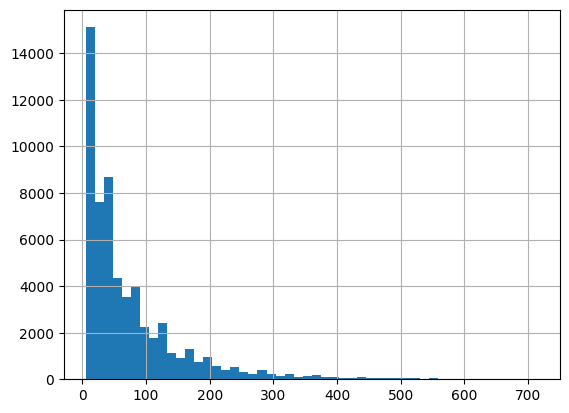

In [73]:
time_to_purchase['time_diff'].hist(bins=50)

In [ ]:
# offer 받은 데이터
received2 = df[df['event'] == 'offer completed'][['customer_id', 'offer_id', 'time']]

# transaction
transaction = df[df['event'] == 'transaction'][['customer_id', 'time']]

# merge
merged = pd.merge(received, transaction, on='customer_id', how='left', suffixes=('_offer', '_trans'))

# 시간 차이
merged['time_diff'] = merged['time_trans'] - merged['time_offer']

# offer 이후 구매만
merged = merged[merged['time_diff'] > 0]

# 최소 구매 시간 (고객+offer 기준)
time_to_purchase = merged.groupby(['customer_id', 'offer_id'])['time_diff'].min().reset_index()

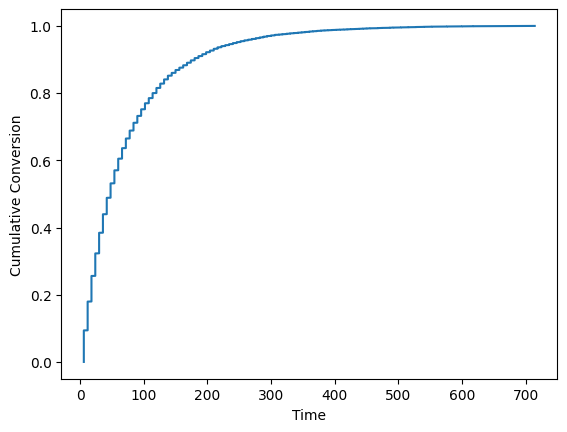

In [74]:
import numpy as np

sorted_time = np.sort(time_to_purchase['time_diff'])
cdf = np.arange(len(sorted_time)) / len(sorted_time)

import matplotlib.pyplot as plt
plt.plot(sorted_time, cdf)
plt.xlabel('Time')
plt.ylabel('Cumulative Conversion')
plt.show()

In [75]:
received = df[df['event'] == 'offer received'][['customer_id', 'offer_id', 'time']]
transaction = df[df['event'] == 'transaction'][['customer_id', 'time']]

rt = pd.merge(received, transaction, on='customer_id', how='left', suffixes=('_rec', '_trans'))
rt['time_diff'] = rt['time_trans'] - rt['time_rec']
rt = rt[rt['time_diff'] > 0]

rt_min = rt.groupby(['customer_id', 'offer_id'])['time_diff'].min().reset_index()

In [76]:
completed = df[df['event'] == 'offer completed'][['customer_id', 'offer_id', 'time']]

rc = pd.merge(received, completed, on=['customer_id', 'offer_id'], how='left', suffixes=('_rec', '_comp'))
rc['time_diff'] = rc['time_comp'] - rc['time_rec']
rc = rc[rc['time_diff'] > 0]

rc_min = rc.groupby(['customer_id', 'offer_id'])['time_diff'].min().reset_index()

In [77]:
ct = pd.merge(completed, transaction, on='customer_id', how='left', suffixes=('_comp', '_trans'))
ct['time_diff'] = ct['time_trans'] - ct['time_comp']
ct = ct[ct['time_diff'] > 0]

ct_min = ct.groupby(['customer_id', 'offer_id'])['time_diff'].min().reset_index()

In [78]:
print("received → transaction")
print(rt_min['time_diff'].describe())

print("\nreceived → completed")
print(rc_min['time_diff'].describe())

print("\ncompleted → transaction")
print(ct_min['time_diff'].describe())

received → transaction
count    59088.000000
mean        75.730199
std         85.045978
min          6.000000
25%         18.000000
50%         48.000000
75%         96.000000
max        714.000000
Name: time_diff, dtype: float64

received → completed
count    27552.000000
mean        63.976699
std         51.469548
min          6.000000
25%         24.000000
50%         48.000000
75%         96.000000
max        576.000000
Name: time_diff, dtype: float64

completed → transaction
count    25932.000000
mean        60.661268
std         66.638266
min          6.000000
25%         18.000000
50%         36.000000
75%         78.000000
max        678.000000
Name: time_diff, dtype: float64


In [79]:
# duration 시간으로 변환 (day → hour)
df['duration_hours'] = df['duration'] * 24

In [80]:
received = df[df['event'] == 'offer received'][['customer_id', 'offer_id', 'time', 'duration_hours']]
transaction = df[df['event'] == 'transaction'][['customer_id', 'time']]

merged = pd.merge(received, transaction, on='customer_id', how='left', suffixes=('_rec', '_trans'))

merged['time_diff'] = merged['time_trans'] - merged['time_rec']
merged = merged[merged['time_diff'] > 0]

In [82]:
df['duration_hours'].describe()

count    167581.000000
mean        158.657700
std          51.267123
min          72.000000
25%         120.000000
50%         168.000000
75%         168.000000
max         240.000000
Name: duration_hours, dtype: float64

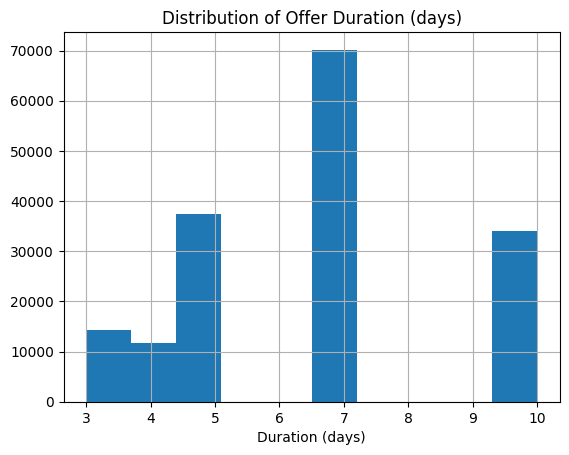

In [83]:
import matplotlib.pyplot as plt

df['duration'].hist(bins=10)
plt.title('Distribution of Offer Duration (days)')
plt.xlabel('Duration (days)')
plt.show()

In [84]:
portfolio.groupby('offer_type')['duration'].value_counts()

offer_type     duration
bogo           7           2
               5           2
discount       10          2
               7           2
informational  4           1
               3           1
Name: count, dtype: int64

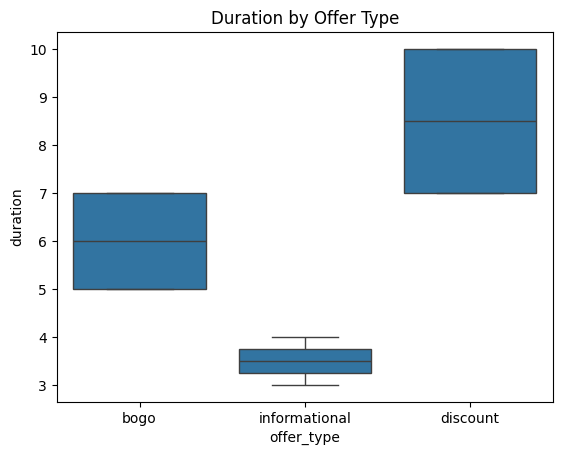

In [85]:
import seaborn as sns

sns.boxplot(x='offer_type', y='duration', data=portfolio)
plt.title('Duration by Offer Type')
plt.show()